In [2]:
import matplotlib.pyplot as plt
import numpy as np

Vmp, Imp, Vmax and Imax for No filter :  [3.757, 1.85, 4.36, 2.92]
Vmp, Imp, Vmax and Imax for With filter 1 (red) :  [3.017, 0.88, 3.396, 1.29]
Vmp, Imp, Vmax and Imax for With filter 2 (pink) :  [3.354, 1.41, 4.024, 2.07]
Vmp, Imp, Vmax and Imax for With filter 3 (green) :  [2.299, 0.51, 2.299, 0.7]
Vmp, Imp, Vmax and Imax for With filter 4 (yellow) :  [3.439, 1.33, 3.982, 1.98]


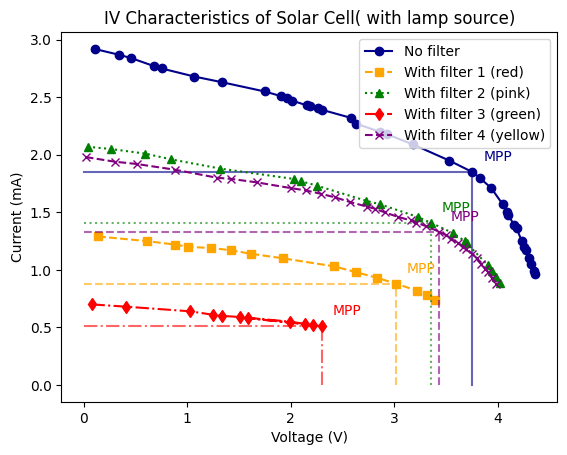

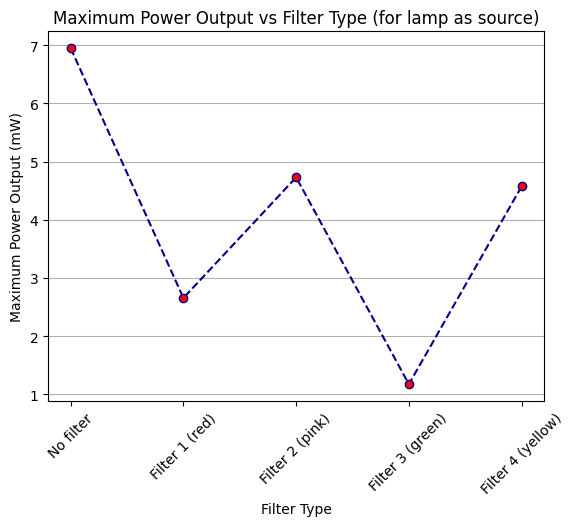

In [2]:
# IV characteristics of Solar Cell with and without filters
# No filter
I0 = [2.92,2.87,2.84,2.77,2.75,2.68,2.63,2.55,2.51,2.49,2.47,2.43,2.42,2.41,2.39,2.32,2.27,2.20,2.18,2.09,1.95,1.85,1.80,1.71,1.57,1.5,1.48,1.39,1.36,1.25,1.2,1.17,1.1,1.05,0.99,0.96] # mA
V0 = [104.1,337,459.2,680.0,753.0,1068,1339,1750,1906,1968,2016,2155,2185,2266,2306,2586,2635,2861,2927,3183,3533,3757,3828,3940,4050,4092,4105,4158,4185,4235,4256,4276,4306,4325,4351,4360] # mV
V0 = [v/1000 for v in V0] # Convert mV to V 


# with filter 1 (red)
I1 = [1.29,1.25,1.22,1.2,1.19,1.17,1.14,1.1,1.03,0.98,0.93,0.88,0.82,0.78,0.74] # mA
V1 = [0.138,0.609,0.878,1.008,1.23,1.427,1.614,1.928,2.423,2.631,2.839,3.017,3.22,3.314,3.396] # V
P1 = [I1[i]*V1[i] for i in range(len(I1))]
# with filter 2 (pink)
I2 = [2.07,2.05,2.01,1.96,1.88,1.79,1.77,1.73,1.60,1.57,1.46,1.41,1.32,1.25,1.23,1.04,0.99,0.94,0.89] # mA
V2 = [0.036,0.2633,0.595,0.845,1.32,2.03,2.102,2.259,2.731,2.864,3.228,3.354,3.569,3.684,3.704,3.907,3.951,3.986,4.024] # V

# with filter 3 (green)
I3 = [0.7,0.68,0.64,0.61,0.6,0.59,0.55,0.53,0.58,0.52,0.51] # mA
V3 = [0.0744,0.4082,1.025,1.247,1.339,1.511,1.989,2.141,1.588,2.215,2.299] # V

# with filter 4 (yellow)
I4 = [1.98,1.94,1.92,1.87,1.8,1.79,1.76,1.71,1.69,1.66,1.63,1.59,1.55,1.53,1.5,1.46,1.43,1.41,1.38,1.33,1.3,1.27,1.23,1.2,1.18,1.14,1.1,1.05,1.01,0.98,0.93,0.88] # mA
V4 = [0.019,0.2987,0.5112,0.883,1.291,1.427,1.675,2.005,2.149,2.296,2.429,2.573,2.735,2.82,2.909,3.038,3.162,3.213,3.31,3.439,3.505,3.552,3.622,3.67,3.7,3.755,3.797,3.841,3.881,3.909,3.945,3.982] # V


def mpp(V,I):
    P = [v * i for v, i in zip(V, I)]
    Vmp = V[np.argmax(P)]
    Imp = I[np.argmax(P)]
    return Vmp,Imp

def plot_mpp(V,I,lab,mark,style,cc):
    plt.plot(V, I, label=lab,linestyle =style, marker=mark,color=cc)
    V_mp,I_mp = mpp(V,I)
    print(f'Vmp, Imp, Vmax and Imax for {lab} : ',[V_mp,I_mp,V[-1],I[0]])
    plt.plot([V_mp, V_mp], [0, I_mp],linestyle=style, color=cc, alpha=0.6)
    plt.plot([0, V_mp], [I_mp, I_mp],linestyle=style, color=cc, alpha=0.6)
    plt.annotate(f"MPP",xy=(V_mp, I_mp),xytext=(8, 8),textcoords='offset points',color=cc,fontsize=10)

plot_mpp(V0,I0,'No filter','o','-','darkblue')
plot_mpp(V1,I1,'With filter 1 (red)' ,  's','--','orange')
plot_mpp(V2,I2,'With filter 2 (pink)',  '^',':','green')
plot_mpp(V3,I3,'With filter 3 (green)', 'd','-.','red')
plot_mpp(V4,I4,'With filter 4 (yellow)','x','--','purple')
plt.title('IV Characteristics of Solar Cell( with lamp source)')
plt.xlabel('Voltage (V)')
plt.ylabel('Current (mA)')
plt.legend()
# plt.grid()
plt.show()

# max power  vs filter type
max_pow_0 = max([v * i for v, i in zip(V0, I0)])
max_pow_1 = max([v * i for v, i in zip(V1, I1)])
max_pow_2 = max([v * i for v, i in zip(V2, I2)])
max_pow_3 = max([v * i for v, i in zip(V3, I3)])
max_pow_4 = max([v * i for v, i in zip(V4, I4)])
filter_types = ['No filter', 'Filter 1 (red)', 'Filter 2 (pink)', 'Filter 3 (green)', 'Filter 4 (yellow)']
max_powers = [max_pow_0, max_pow_1, max_pow_2, max_pow_3, max_pow_4]
plt.plot(filter_types,max_powers,linestyle ='--', marker = 'o',mfc = 'r',c='darkblue')
plt.title('Maximum Power Output vs Filter Type (for lamp as source)')
plt.xlabel('Filter Type')
plt.ylabel('Maximum Power Output (mW)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

Vmp, Imp, Vmax and Imax for No filter :  [5.036, 64.5, 5.786, 68.1]
Vmp, Imp, Vmax and Imax for With filter 1 (red) :  [5.019, 41.66, 5.555, 45.85]
Vmp, Imp, Vmax and Imax for With filter 2 (green) :  [4.553, 27.28, 5.438, 28.72]
Vmp, Imp, Vmax and Imax for With filter 3 (pink) :  [4.585, 32.31, 5.594, 38.28]
Vmp, Imp, Vmax and Imax for With filter 4 (yellow) :  [3.443, 26.14, 5.323, 36.47]


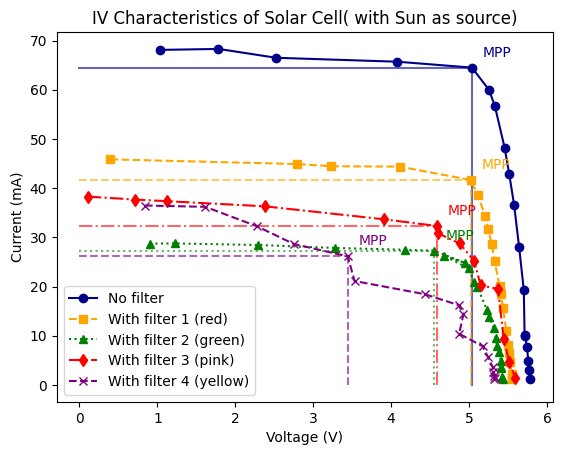

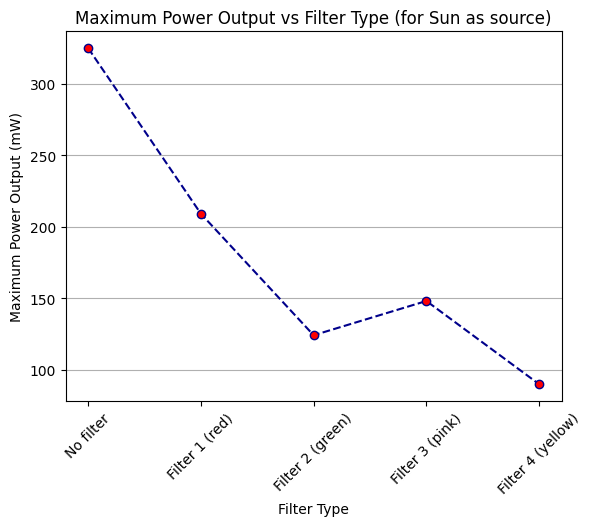

In [3]:
# Sun as a source
# No filter
I0_s = [68.1,68.3,66.5,65.7,64.5,60,56.73,48.21,42.85,36.53,27.99,19.26,10,10.17,7.71,4.9,2.94,1.28] # mA
V0_s = [1.036,1.784,2.524,4.079,5.036,5.255,5.33,5.456,5.515,5.578,5.642,5.702,5.712,5.719,5.742,5.760,5.771,5.786] # mV 
# with filter 1 (red)
I1_s = [45.85, 44.90, 44.45, 44.38, 41.66, 38.53, 34.25, 31.68, 28.58,25.22, 20.02, 18.48, 15.68, 10.91, 8.02, 6.49, 4.63, 2.20, 1.48,1.23] # mA
V1_s = [0.398, 2.791, 3.233, 4.109, 5.019, 5.116, 5.207, 5.246, 5.290,5.326, 5.392, 5.406, 5.435, 5.478, 5.497, 5.510, 5.526, 5.549, 5.554,5.555] # V
# with filter 2 (green)
I2_s = [28.72, 28.76, 28.45, 27.84, 27.48, 27.28, 24.81,26.3,23.68,21.01, 19.95, 15.24, 13.74, 11.61, 9.49, 7.92, 6.69, 4.82, 3.73,3.42,1.71,1.28] # mA
V2_s = [0.904, 1.220, 2.287, 3.284, 4.181, 4.553, 4.948, 4.674, 4.997,5.059, 5.106, 5.228, 5.258, 5.315, 5.339, 5.361, 5.383, 5.408, 5.407,5.404,5.426,5.438] # V
# with filter 3 (pink)
I3_s = [38.28, 37.68, 37.35, 36.30, 33.66,32.31, 30.87, 28.75, 25.27,20.24, 19.50, 9.35, 4.73, 1.33] # mA
V3_s = [0.109, 0.713, 1.125, 2.382, 3.912,4.585, 4.595, 4.880, 5.062,5.149, 5.371, 5.444, 5.515, 5.594] # V
# with filter 4 (yellow)
I4_s = [36.47, 36.2, 32.25, 28.64, 26.14,21.12, 18.45, 16.22, 14.42, 10.40,7.87, 5.77, 3.60, 2.64, 1.86,1.48, 1.19] # mA
V4_s = [0.840, 1.616, 2.278, 2.751, 3.443,3.530, 4.430, 4.865, 4.928, 4.872,5.173, 5.240, 5.303, 5.311, 5.323,5.326, 5.323] # V

# Plots
plot_mpp(V0_s,I0_s,'No filter','o','-','darkblue')
plot_mpp(V1_s,I1_s,'With filter 1 (red)' ,  's','--','orange')
plot_mpp(V2_s,I2_s,'With filter 2 (green)',  '^',':','green')
plot_mpp(V3_s,I3_s,'With filter 3 (pink)', 'd','-.','red')
plot_mpp(V4_s,I4_s,'With filter 4 (yellow)','x','--','purple')
plt.title('IV Characteristics of Solar Cell( with Sun as source)')
plt.xlabel('Voltage (V)')
plt.ylabel('Current (mA)')
plt.legend()
# plt.grid()
plt.show()

# max power  vs filter type for Sun as source
max_pow_0_s = max([v * i for v, i in zip(V0_s, I0_s)])
max_pow_1_s = max([v * i for v, i in zip(V1_s, I1_s)])
max_pow_2_s = max([v * i for v, i in zip(V2_s, I2_s)])
max_pow_3_s = max([v * i for v, i in zip(V3_s, I3_s)])
max_pow_4_s = max([v * i for v, i in zip(V4_s, I4_s)])
filter_types_s = ['No filter', 'Filter 1 (red)', 'Filter 2 (green)', 'Filter 3 (pink)', 'Filter 4 (yellow)']
max_powers_s = [max_pow_0_s, max_pow_1_s, max_pow_2_s, max_pow_3_s, max_pow_4_s]
plt.plot(filter_types_s,max_powers_s,linestyle ='--', marker = 'o',mfc = 'r',c='darkblue')
plt.title('Maximum Power Output vs Filter Type (for Sun as source)')
plt.xlabel('Filter Type')
plt.ylabel('Maximum Power Output (mW)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()